<center>
    <h2>Actividad N°8</h2>
    <h3>Transformaciones avanzadas</h3>
</center>
<p>Estudiante: Francisco Pérez (8-841-1013)</p>
<p>Profesor: Dr. Nicolas A. Samaniego F.</p>


In [1]:
from IPython.display import HTML, Math, Latex, display
import numpy as np
import matplotlib.pyplot as plt
from sympy import Symbol, Lambda, Matrix
from sympy.printing import latex
from math import sin, cos, pi

class Poligono():
    def __init__(self, *puntos):
        self.puntos = [p for p in puntos]
        self.puntos_grafica = self.puntos
        self.p_matrices = []
        for x, y in self.puntos:
            self.p_matrices.append(Matrix([[x], [y], [1]]))
        
    def transformar(self, t):
        for i in range(len(self.p_matrices)):
            p = self.p_matrices[i]
            pf = t * p
            self.p_matrices[i] = pf
            display(Latex("$${} * {} = {}$$".format(latex(p), latex(t), latex(pf))))
        self.matriz_a_puntos(self.p_matrices)
            
    def matriz_a_puntos(self, p_ms):
        puntos = []
        for m in p_ms:
            p = m.tolist()
            puntos.append([self.redondeo(p[0][0]), self.redondeo(p[1][0])])
        self.puntos_grafica = puntos
        
    def redondeo(self, n):
        # Para evitar el redondeo del banquero
        if int(n) % 2 == 0:
            r = round(n + 1) - 1
        else:
            r = round(n)
        return r
    
    def graficar(self, color_map="Set3", color_linea="grey"):
        print("Puntos: ", self.puntos_grafica)
        lista_x = [p[0] for p in self.puntos_grafica]
        lista_y = [p[1] for p in self.puntos_grafica]
        rebase_x = [i - min(lista_x) for i in lista_x]
        rebase_y = [i - min(lista_y) for i in lista_y]
        imagen = np.zeros((max(rebase_y)+1, max(rebase_x)+1))
                
        for x, y in zip(rebase_x, rebase_y):
            imagen[y][x] = 2

        imagen = np.flipud(imagen)
        plt.xticks(range(max(rebase_x)+1), range(min(lista_x), max(lista_x)+1))
        plt.yticks(range(max(rebase_y)+1), range(max(lista_y), min(lista_y)-1, -1))
        plt.rcParams['figure.figsize'] = [8,8]
        for i in range(max(rebase_x)+1):
            plt.axvline(i+0.5, color=color_linea, linestyle='--', linewidth=1)
        for i in range(max(rebase_y)+1):
            plt.axhline(i+0.5, color=color_linea, linestyle='--', linewidth=1)
        plt.imshow(imagen, interpolation="nearest", cmap=plt.get_cmap(color_map))
        

<h4>Problema 1</h4>
<p>A partir del polígono definido por los puntos (0,0) (6,0) (6,8) (0,8) (3,3) utilice la matriz de recorte para graficar los resultados al colocar los siguientes valores en las posiciones indicadas a continuación:</p>
<ol>
    <li>Un 1 en la posición 2,1</li>
    <li>Un 1 en la posición 1,2</li>
</ol>

Puntos:  [[0, 0], [6, 0], [6, 8], [0, 8], [3, 3]]


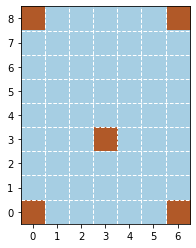

In [2]:
puntos = {
    "p1": [0,0],
    "p2": [6,0],
    "p3": [6,8],
    "p4": [0,8],
    "p5": [3,3]
}

poligono_1 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"], puntos["p4"], puntos["p5"])
poligono_1.graficar("Paired", "white")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Puntos:  [[0, 0], [6, 6], [6, 14], [0, 8], [3, 6]]


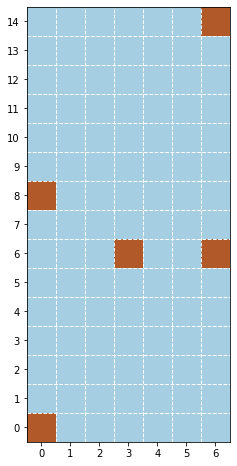

In [4]:
# Problema 1.1
# Matriz de recorte con 1 en la posición 2,1

problema_1_1 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"], puntos["p4"], puntos["p5"])
r1 = Matrix([[1, 0, 0], [1, 1, 0], [0, 0, 1]])
problema_1_1.transformar(r1)
problema_1_1.graficar("Paired", "white")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Puntos:  [[0, 0], [6, 0], [14, 8], [8, 8], [6, 3]]


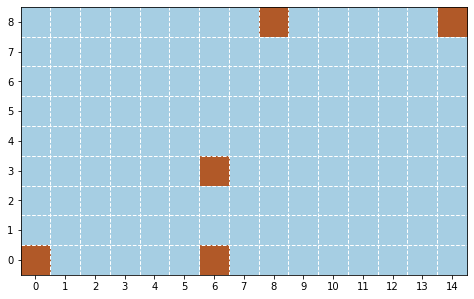

In [5]:
# Problema 1.2
# Matriz de recorte con 1 en la posición 1,2

problema_1_2 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"], puntos["p4"], puntos["p5"])
r2 = Matrix([[1, 1, 0], [0, 1, 0], [0, 0, 1]])
problema_1_2.transformar(r2)
problema_1_2.graficar("Paired", "white")

<h4>Problema 2</h4>
<p>A partir del polígono definido por los puntos (0,0) (6,0) (6,8) (0,8) (3,3) utilice la matriz de simetría para graficar los resultados al colocar los siguientes valores en las posiciones indicadas a continuación:</p>
<ol>
    <li>Un -1 en la posición 1,1</li>
    <li>Un -1 en la posición 2,2</li>
    <li>Un -1 en las posiciones 1,1 y 2,2</li>
</ol>

Puntos:  [[0, 0], [6, 0], [6, 8], [0, 8], [3, 3]]


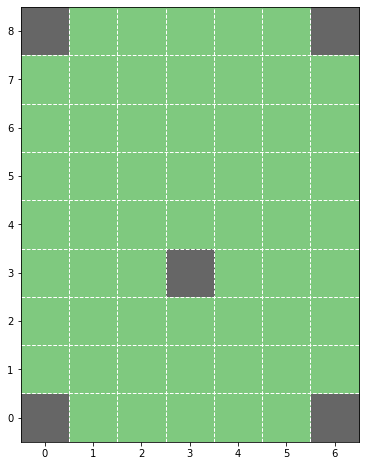

In [11]:
puntos = {
    "p1": [0,0],
    "p2": [6,0],
    "p3": [6,8],
    "p4": [0,8],
    "p5": [3,3]
}

poligono_2 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"], puntos["p4"], puntos["p5"])
poligono_2.graficar("Accent", "White")

In [12]:
# Problema 2.1
# Matriz de simetría con -1 en la posición 1,1

problema_2_1 = Poligono(poligono["p1"], poligono["p2"], poligono["p3"], poligono["p4"], poligono["p5"])
s1 = Matrix([[-1, 0, 0], [0, 1, 0], [0, 0, 1]])
problema_2_1.transformar(s1)
problema_2_1.graficar("Accent", "White")

NameError: name 'poligono' is not defined

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Puntos:  [[0, 0], [6, 0], [6, -8], [0, -8], [3, -3]]


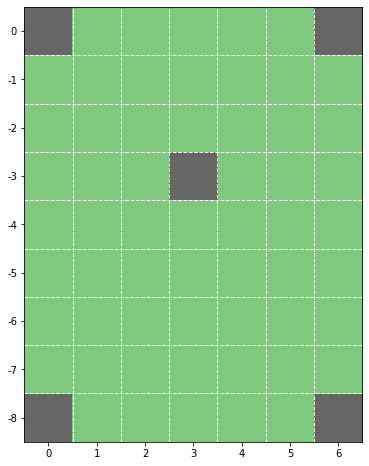

In [8]:
# Problema 2.2
# Matriz de simetría con -1 en la posición 2,2

problema_2_2 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"], puntos["p4"], puntos["p5"])
s2 = Matrix([[1, 0, 0], [0, -1, 0], [0, 0, 1]])
problema_2_2.transformar(s2)
problema_2_2.graficar("Accent", "White")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Puntos:  [[0, 0], [-6, 0], [-6, -8], [0, -8], [-3, -3]]


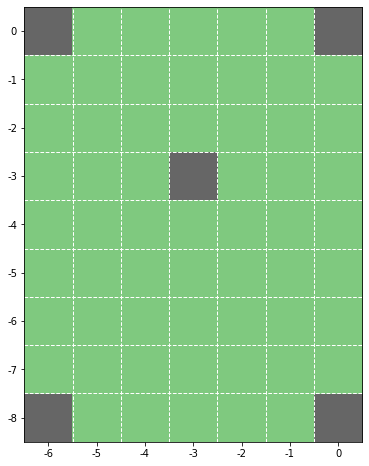

In [9]:
# Problema 2.3
# Matriz de simetría con -1 en la posición 1,1 y 2,2

problema_2_3 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"], puntos["p4"], puntos["p5"])
s3 = Matrix([[-1, 0, 0], [0, -1, 0], [0, 0, 1]])
problema_2_3.transformar(s3)
problema_2_3.graficar("Accent", "White")

Puntos:  [[0, 9], [5, 2], [9, 8]]


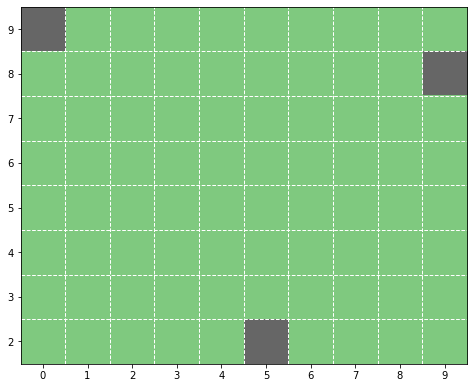

In [10]:
# Examen

puntos = {
    "p1": [0,9],
    "p2": [5,2],
    "p3": [9,8]
}

poligono_2 = Poligono(puntos["p1"], puntos["p2"], puntos["p3"])
poligono_2.graficar("Accent", "White")